In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
trainTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

testTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainDir = "D:/SeniorProject/LLMImageLabels"
testDir = "D:/SeniorProject/CroppedImages"

trainDataset = ImageFolder(root=trainDir, transform=trainTransform)
testDataset = ImageFolder(root=testDir, transform=testTransform)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [4]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [5]:
def trainModel(model, numEpochs):

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        
        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")

        # If the validation accuracy improves, save the model
        if epoch == 0 or validAccuracies[-1] > max(validAccuracies[:-1]):
            torch.save(model.state_dict(), "best_modelReLU.pt")
            print("Model saved!")

    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

In [6]:
def plotConfusionMatrix(model, testLoader):
    modelPrediction = []
    realLabels = []
    classNames = trainDataset.classes

    with torch.no_grad():
        for inputs, labels in testLoader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            modelPrediction.extend(preds.cpu().numpy())
            realLabels.extend(labels.cpu().numpy())

    cm = confusion_matrix(realLabels, modelPrediction)
    labels_unique = sorted(set(classNames))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_unique, yticklabels=labels_unique)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# EvenBetterNet

In [32]:
class ResidualBlock(nn.Module):
    def __init__(self, inChannels, outChannels, stride=1):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(inChannels, outChannels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(outChannels),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(outChannels, outChannels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(outChannels)
        )

        if inChannels != outChannels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(inChannels, outChannels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(outChannels)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out += identity
        return self.relu(out)


In [33]:
class EvenBetterNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = ResidualBlock(3, 32)
        self.l2 = ResidualBlock(32, 64, stride=2)
        self.l3 = ResidualBlock(64, 128, stride=2)
        self.l4 = ResidualBlock(128, 256, stride=2)
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 30)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# EvenBetterNet with .5 Dropout

Epoch 1/150, Train Loss: 2.6247, Train Accuracy: 0.2338, Validation Loss: 2.7936, Validation Accuracy: 0.1709
Epoch 2/150, Train Loss: 2.1474, Train Accuracy: 0.3525, Validation Loss: 2.3813, Validation Accuracy: 0.2969
Epoch 3/150, Train Loss: 1.9085, Train Accuracy: 0.4196, Validation Loss: 2.2634, Validation Accuracy: 0.3311
Epoch 4/150, Train Loss: 1.7471, Train Accuracy: 0.4740, Validation Loss: 2.1766, Validation Accuracy: 0.3477
Epoch 5/150, Train Loss: 1.6063, Train Accuracy: 0.5115, Validation Loss: 2.0555, Validation Accuracy: 0.3525
Epoch 6/150, Train Loss: 1.4787, Train Accuracy: 0.5526, Validation Loss: 2.1268, Validation Accuracy: 0.3516
Epoch 7/150, Train Loss: 1.3879, Train Accuracy: 0.5736, Validation Loss: 1.9950, Validation Accuracy: 0.4043
Epoch 8/150, Train Loss: 1.3096, Train Accuracy: 0.5988, Validation Loss: 1.8865, Validation Accuracy: 0.3984
Epoch 9/150, Train Loss: 1.2430, Train Accuracy: 0.6200, Validation Loss: 1.7408, Validation Accuracy: 0.4609
Epoch 10/1

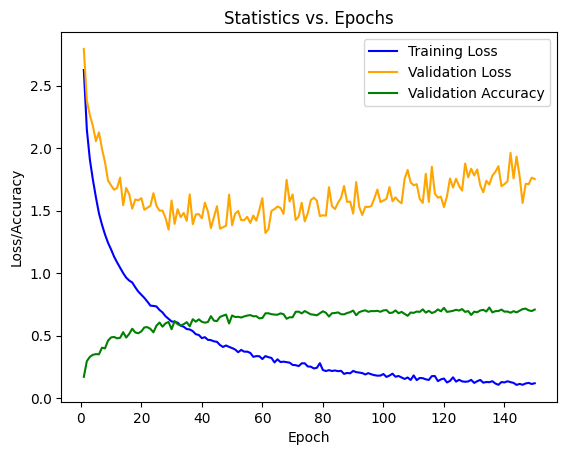

Accuracy: 70.8984%


In [11]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

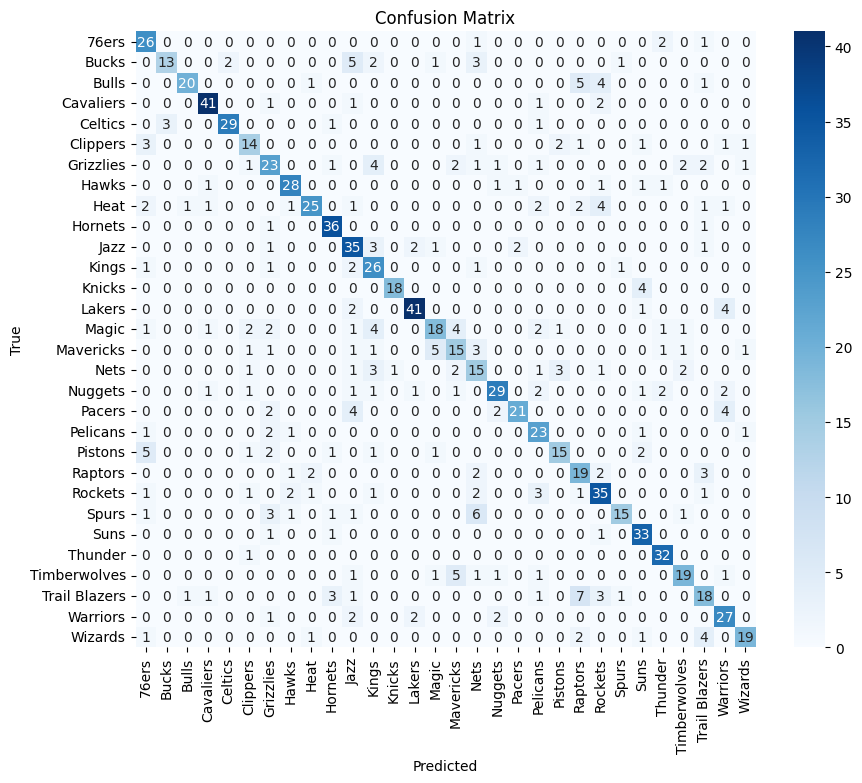

In [24]:
modelPrediction = []
realLabels = []
classNames = trainDataset.classes

with torch.no_grad():
    for inputs, labels in testLoader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        modelPrediction.extend(preds.cpu().numpy())
        realLabels.extend(labels.cpu().numpy())

cm = confusion_matrix(realLabels, modelPrediction)
labels_unique = sorted(set(classNames))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# EvenBetterNet with .2 Dropout

Epoch 1/150, Train Loss: 2.5370, Train Accuracy: 0.2594, Validation Loss: 2.6092, Validation Accuracy: 0.2549
Epoch 2/150, Train Loss: 2.0373, Train Accuracy: 0.3786, Validation Loss: 2.3049, Validation Accuracy: 0.2812
Epoch 3/150, Train Loss: 1.8096, Train Accuracy: 0.4466, Validation Loss: 2.2441, Validation Accuracy: 0.2998
Epoch 4/150, Train Loss: 1.6585, Train Accuracy: 0.4975, Validation Loss: 1.9812, Validation Accuracy: 0.3750
Epoch 5/150, Train Loss: 1.5229, Train Accuracy: 0.5390, Validation Loss: 2.0450, Validation Accuracy: 0.3428
Epoch 6/150, Train Loss: 1.4285, Train Accuracy: 0.5649, Validation Loss: 1.9076, Validation Accuracy: 0.4160
Epoch 7/150, Train Loss: 1.3362, Train Accuracy: 0.5965, Validation Loss: 1.7606, Validation Accuracy: 0.4316
Epoch 8/150, Train Loss: 1.2654, Train Accuracy: 0.6207, Validation Loss: 1.7264, Validation Accuracy: 0.4707
Epoch 9/150, Train Loss: 1.2151, Train Accuracy: 0.6299, Validation Loss: 1.7378, Validation Accuracy: 0.4912
Epoch 10/1

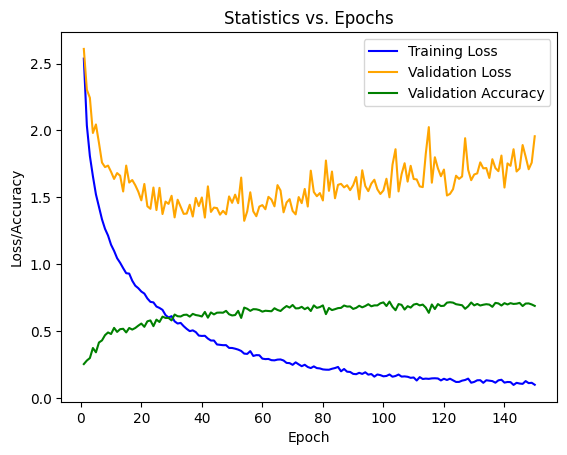

Accuracy: 68.9453%


In [9]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 150)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

# EvenBetterNet with .5 dropout selected, added a fourth layer

Epoch 1/75, Train Loss: 2.6426, Train Accuracy: 0.2238, Validation Loss: 2.5556, Validation Accuracy: 0.2281
Epoch 2/75, Train Loss: 2.0795, Train Accuracy: 0.3684, Validation Loss: 2.1462, Validation Accuracy: 0.3215
Epoch 3/75, Train Loss: 1.8167, Train Accuracy: 0.4419, Validation Loss: 2.0235, Validation Accuracy: 0.3224
Epoch 4/75, Train Loss: 1.6581, Train Accuracy: 0.4961, Validation Loss: 1.8271, Validation Accuracy: 0.4148
Epoch 5/75, Train Loss: 1.4895, Train Accuracy: 0.5421, Validation Loss: 1.8789, Validation Accuracy: 0.4052
Epoch 6/75, Train Loss: 1.4172, Train Accuracy: 0.5672, Validation Loss: 1.7362, Validation Accuracy: 0.4620
Epoch 7/75, Train Loss: 1.3365, Train Accuracy: 0.5899, Validation Loss: 1.7851, Validation Accuracy: 0.4524
Epoch 8/75, Train Loss: 1.2478, Train Accuracy: 0.6175, Validation Loss: 1.6907, Validation Accuracy: 0.5053
Epoch 9/75, Train Loss: 1.1931, Train Accuracy: 0.6375, Validation Loss: 1.6086, Validation Accuracy: 0.4918
Epoch 10/75, Train 

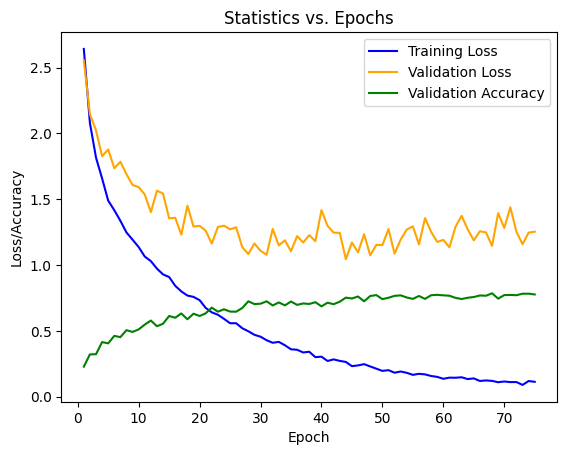

Accuracy: 77.6708%


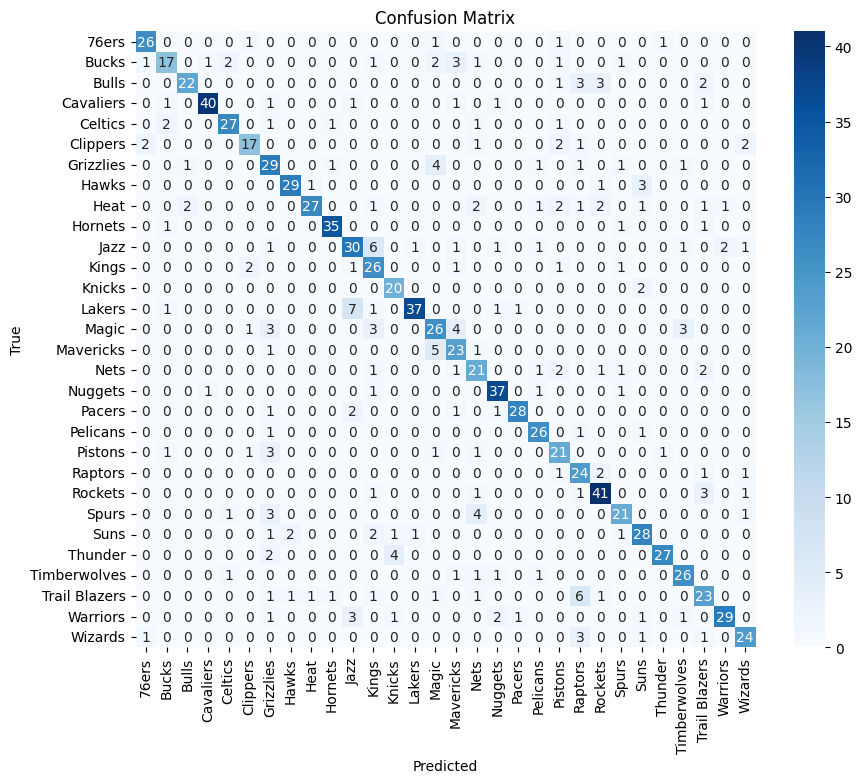

In [35]:
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

In [36]:
torch.save(model.state_dict(), "EvenBetterNet.pt")

# Trying GELU instead of ReLU

Epoch 1/75, Train Loss: 2.5949, Train Accuracy: 0.2373, Validation Loss: 2.5211, Validation Accuracy: 0.2493
Epoch 2/75, Train Loss: 2.0313, Train Accuracy: 0.3770, Validation Loss: 2.2854, Validation Accuracy: 0.2878
Epoch 3/75, Train Loss: 1.7717, Train Accuracy: 0.4549, Validation Loss: 1.8932, Validation Accuracy: 0.4110
Epoch 4/75, Train Loss: 1.5562, Train Accuracy: 0.5197, Validation Loss: 1.9162, Validation Accuracy: 0.3994
Epoch 5/75, Train Loss: 1.4083, Train Accuracy: 0.5660, Validation Loss: 1.6660, Validation Accuracy: 0.4832
Epoch 6/75, Train Loss: 1.3079, Train Accuracy: 0.5992, Validation Loss: 1.5826, Validation Accuracy: 0.5072
Epoch 7/75, Train Loss: 1.2361, Train Accuracy: 0.6240, Validation Loss: 1.5650, Validation Accuracy: 0.5149
Epoch 8/75, Train Loss: 1.1412, Train Accuracy: 0.6558, Validation Loss: 1.5820, Validation Accuracy: 0.5072
Epoch 9/75, Train Loss: 1.0593, Train Accuracy: 0.6746, Validation Loss: 1.5436, Validation Accuracy: 0.5342
Epoch 10/75, Train 

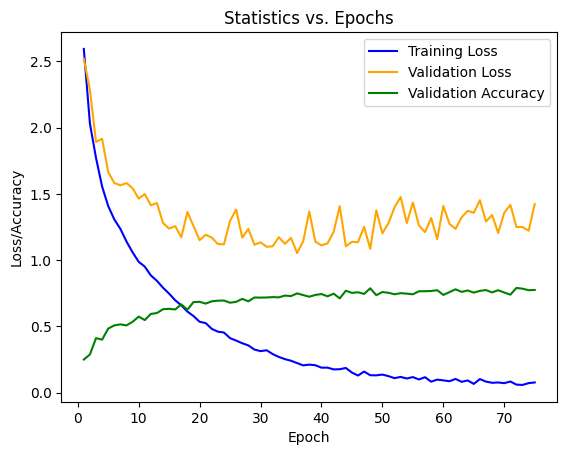

Accuracy: 77.4783%


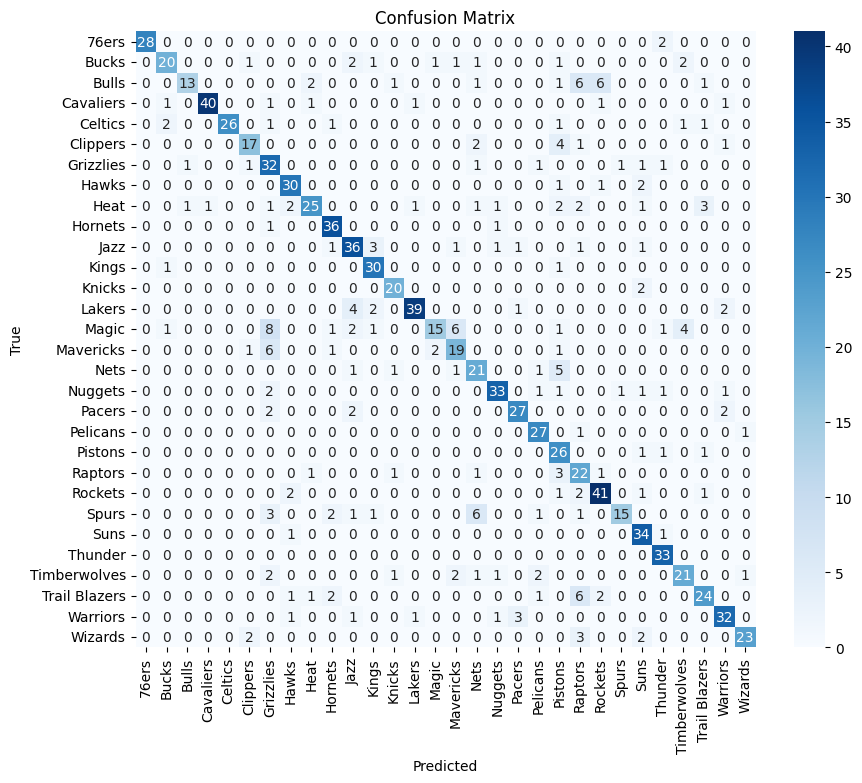

In [40]:
from models.evenbetternet import EvenBetterNet

model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

# Trying SiLU isntead of GELU

Epoch 1/75, Train Loss: 2.4926, Train Accuracy: 0.2632, Validation Loss: 2.4180, Validation Accuracy: 0.2666
Epoch 2/75, Train Loss: 1.9331, Train Accuracy: 0.4077, Validation Loss: 2.1007, Validation Accuracy: 0.3340
Epoch 3/75, Train Loss: 1.6748, Train Accuracy: 0.4847, Validation Loss: 1.8373, Validation Accuracy: 0.4139
Epoch 4/75, Train Loss: 1.5008, Train Accuracy: 0.5354, Validation Loss: 1.7957, Validation Accuracy: 0.4254
Epoch 5/75, Train Loss: 1.3698, Train Accuracy: 0.5796, Validation Loss: 1.6753, Validation Accuracy: 0.4726
Epoch 6/75, Train Loss: 1.2513, Train Accuracy: 0.6094, Validation Loss: 1.6181, Validation Accuracy: 0.4995
Epoch 7/75, Train Loss: 1.1760, Train Accuracy: 0.6425, Validation Loss: 1.6346, Validation Accuracy: 0.4889
Epoch 8/75, Train Loss: 1.1080, Train Accuracy: 0.6581, Validation Loss: 1.5828, Validation Accuracy: 0.5438
Epoch 9/75, Train Loss: 1.0534, Train Accuracy: 0.6817, Validation Loss: 1.5457, Validation Accuracy: 0.5111
Epoch 10/75, Train 

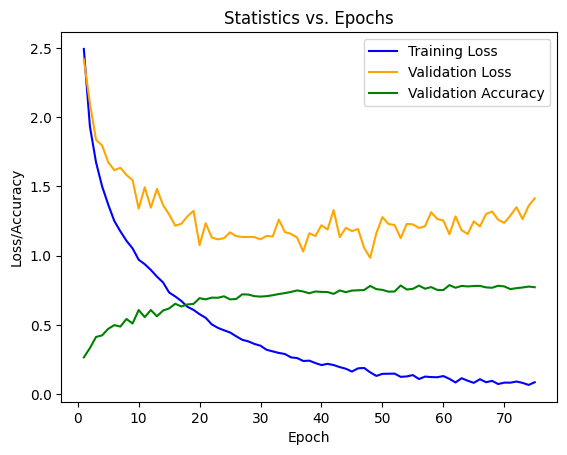

Accuracy: 77.2859%


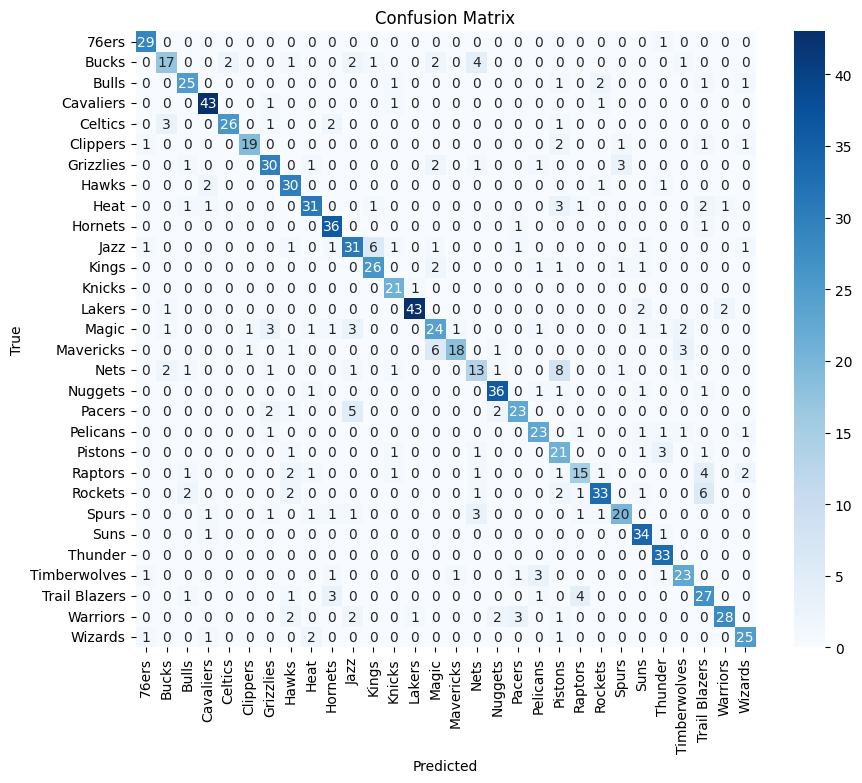

In [7]:
from models.evenbetternet import EvenBetterNet

model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

# 5th layer added using GELU

Epoch 1/75, Train Loss: 2.5793, Train Accuracy: 0.2405, Validation Loss: 2.5648, Validation Accuracy: 0.2358
Model saved!
Epoch 2/75, Train Loss: 1.9681, Train Accuracy: 0.4068, Validation Loss: 2.4345, Validation Accuracy: 0.2608
Model saved!
Epoch 3/75, Train Loss: 1.6869, Train Accuracy: 0.4843, Validation Loss: 1.8782, Validation Accuracy: 0.4013
Model saved!
Epoch 4/75, Train Loss: 1.5089, Train Accuracy: 0.5341, Validation Loss: 1.7897, Validation Accuracy: 0.4167
Model saved!
Epoch 5/75, Train Loss: 1.3581, Train Accuracy: 0.5894, Validation Loss: 1.6466, Validation Accuracy: 0.4928
Model saved!
Epoch 6/75, Train Loss: 1.2344, Train Accuracy: 0.6261, Validation Loss: 1.6039, Validation Accuracy: 0.5005
Model saved!
Epoch 7/75, Train Loss: 1.1305, Train Accuracy: 0.6589, Validation Loss: 1.5345, Validation Accuracy: 0.5361
Model saved!
Epoch 8/75, Train Loss: 1.0315, Train Accuracy: 0.6939, Validation Loss: 1.4841, Validation Accuracy: 0.5659
Model saved!
Epoch 9/75, Train Loss: 

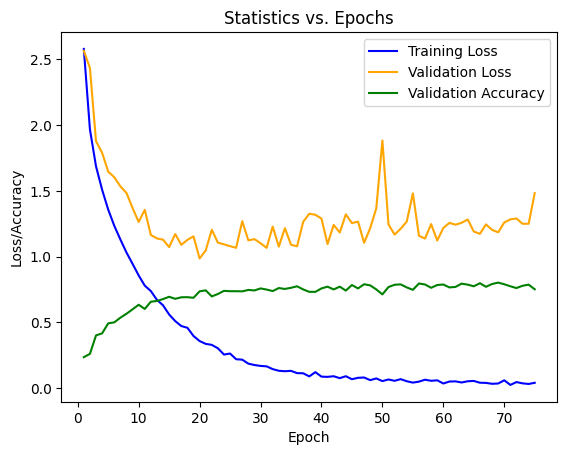

Accuracy: 75.1684%


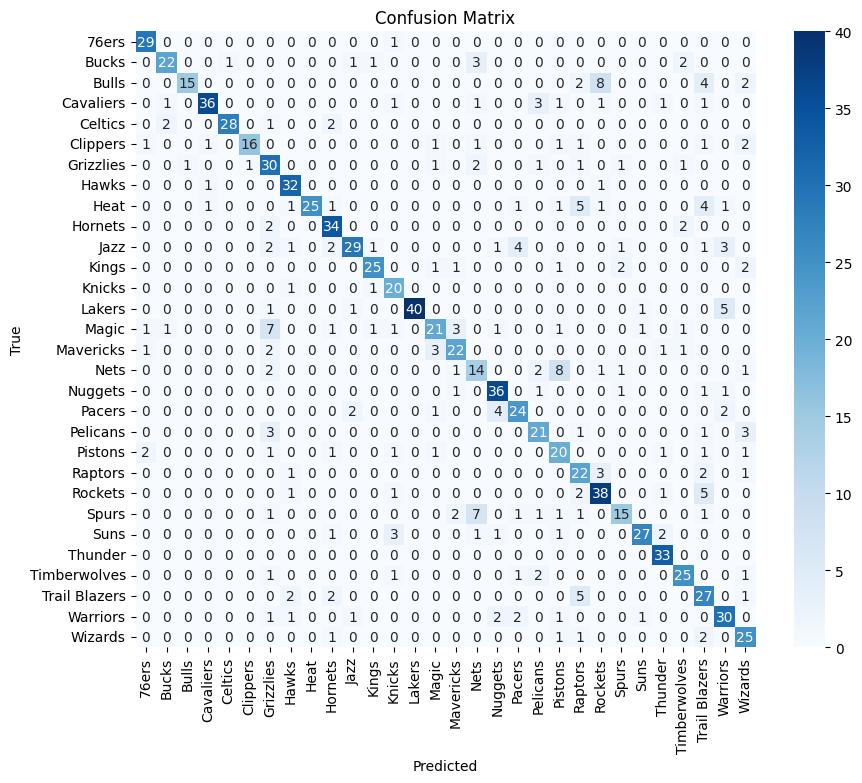

In [7]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

In [ ]:
from models.evenbetternet import EvenBetterNet
model = EvenBetterNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 75)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")
plotConfusionMatrix(model, testLoader)

Epoch 1/75, Train Loss: 2.6803, Train Accuracy: 0.2111, Validation Loss: 2.6138, Validation Accuracy: 0.2194
Model saved!
Epoch 2/75, Train Loss: 2.1742, Train Accuracy: 0.3388, Validation Loss: 2.5209, Validation Accuracy: 0.2406
Model saved!
Epoch 3/75, Train Loss: 1.9274, Train Accuracy: 0.4079, Validation Loss: 2.2409, Validation Accuracy: 0.2859
Model saved!
Epoch 4/75, Train Loss: 1.7426, Train Accuracy: 0.4593, Validation Loss: 1.9781, Validation Accuracy: 0.3715
Model saved!
Epoch 5/75, Train Loss: 1.6025, Train Accuracy: 0.5037, Validation Loss: 1.7506, Validation Accuracy: 0.4533
Model saved!
Epoch 6/75, Train Loss: 1.4848, Train Accuracy: 0.5381, Validation Loss: 2.3452, Validation Accuracy: 0.3330
Epoch 7/75, Train Loss: 1.3917, Train Accuracy: 0.5719, Validation Loss: 1.6788, Validation Accuracy: 0.4783
Model saved!
Epoch 8/75, Train Loss: 1.2997, Train Accuracy: 0.6019, Validation Loss: 1.8573, Validation Accuracy: 0.4206
Epoch 9/75, Train Loss: 1.2065, Train Accuracy: 0.